In [1]:
#preprocessing 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ======================
# LOAD
# ======================

df = pd.read_csv(r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\raw\nasa_weather_daily.csv")

print("Raw Shape:", df.shape)

# ======================
# DATE
# ======================

df["date"] = pd.to_datetime(
    df["date"],
    format="%Y%m%d"
)

df["tahun"] = df["date"].dt.year

# ======================
# CLEAN NAMA KABUPATEN
# ======================

df["kabupaten"] = (
    df["kabupaten_kota"]
    .str.upper()
    .str.replace("KABUPATEN ", "", regex=False)
    .str.replace("KOTA ", "", regex=False)
    .str.strip()
)

# ======================
# AGGREGATE YEARLY
# ======================

weather_yearly = (
    df.groupby(
        ["kabupaten", "tahun"],
        as_index=False
    )
    .agg({
        "temperature": "mean",
        "temp_max": "mean",
        "temp_min": "mean",
        "rainfall": "sum",
        "humidity": "mean",
        "wind_speed": "mean",
        "solar_radiation": "mean"
    })
)

weather_yearly.to_csv(r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\clean\weather_yearly.csv")
index=False

print(weather_yearly.head())
print(weather_yearly.shape)

Raw Shape: (2065252, 11)
    kabupaten  tahun  temperature   temp_max   temp_min  rainfall   humidity  \
0  ACEH BARAT   2015    26.452110  27.958082  25.246904   2443.15  83.821644   
1  ACEH BARAT   2016    26.562650  28.130601  25.324016   3299.55  84.334399   
2  ACEH BARAT   2017    26.343233  27.936356  25.094658   2628.98  83.402000   
3  ACEH BARAT   2018    26.383507  27.876822  25.236767   2826.55  83.776986   
4  ACEH BARAT   2019    26.726247  28.311479  25.519671   2237.04  83.668603   

   wind_speed  solar_radiation  
0    1.453260        17.427973  
1    1.474973        17.387186  
2    1.462219        17.314767  
3    1.437233        17.310822  
4    1.419205        17.766027  
(5368, 9)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2065252 entries, 0 to 2065251
Data columns (total 13 columns):
 #   Column           Dtype         
---  ------           -----         
 0   kabupaten_kota   str           
 1   latitude         float64       
 2   longitude        float64       
 3   date             datetime64[us]
 4   temperature      float64       
 5   temp_max         float64       
 6   temp_min         float64       
 7   rainfall         float64       
 8   humidity         float64       
 9   wind_speed       float64       
 10  solar_radiation  float64       
 11  tahun            int32         
 12  kabupaten        str           
dtypes: datetime64[us](1), float64(9), int32(1), str(2)
memory usage: 254.0 MB


In [ ]:
df = pd.read_csv(r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\raw\nasa_weather_daily.csv")
df.head()

,kabupaten_kota,latitude,longitude,date,temperature,temp_max,temp_min,rainfall,humidity,wind_speed,solar_radiation
0,KABUPATEN SIMEULUE,2.46158,96.38105,20150101,28.19,28.69,27.46,0.63,75.55,1.47,13.44
1,KABUPATEN SIMEULUE,2.46158,96.38105,20150102,27.93,28.32,27.36,3.50,77.87,1.92,21.27
2,KABUPATEN SIMEULUE,2.46158,96.38105,20150103,27.56,28.16,26.68,1.23,77.69,2.74,21.24
3,KABUPATEN SIMEULUE,2.46158,96.38105,20150104,27.10,27.53,26.76,5.20,78.94,1.55,16.05
4,KABUPATEN SIMEULUE,2.46158,96.38105,20150105,27.55,28.37,26.74,5.13,74.93,1.48,12.51


In [8]:
print(df.describe())

           latitude     longitude          date   temperature      temp_max  \
count  2.065252e+06  2.065252e+06  2.065252e+06  2.065252e+06  2.065252e+06   
mean  -3.208467e+00  1.133094e+02  2.020067e+07  2.578709e+01  2.855286e+01   
std    3.875354e+00  1.099909e+01  3.162545e+04  2.325702e+00  2.357833e+00   
min   -1.073864e+01  9.532080e+01  2.015010e+07  7.740000e+00  9.820000e+00   
25%   -6.883330e+00  1.045121e+02  2.017100e+07  2.478000e+01  2.751000e+01   
50%   -3.413235e+00  1.115771e+02  2.020070e+07  2.616000e+01  2.866000e+01   
75%   -2.098200e-01  1.205049e+02  2.023040e+07  2.730000e+01  2.975000e+01   
max    5.892850e+00  1.407625e+02  2.025123e+07  3.229000e+01  4.246000e+01   

           temp_min      rainfall      humidity    wind_speed  solar_radiation  
count  2.065252e+06  2.065252e+06  2.065252e+06  2.065252e+06     2.065252e+06  
mean   2.365200e+01  7.113386e+00  8.428193e+01  1.624831e+00     1.804798e+01  
std    2.782643e+00  1.065757e+01  6.867964e+

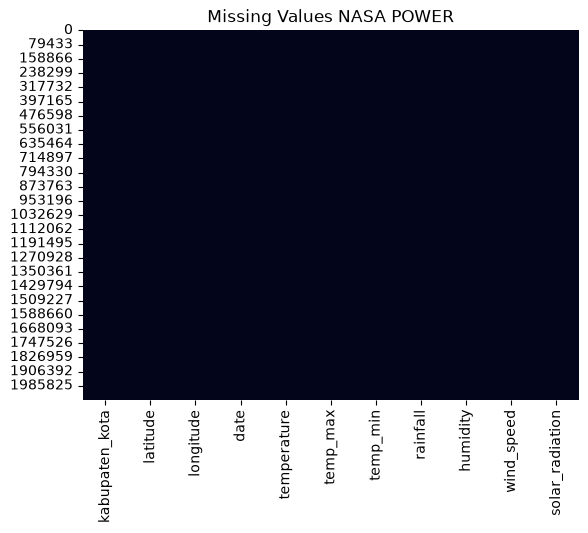

In [12]:
#missing values
sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values NASA POWER")
plt.show()

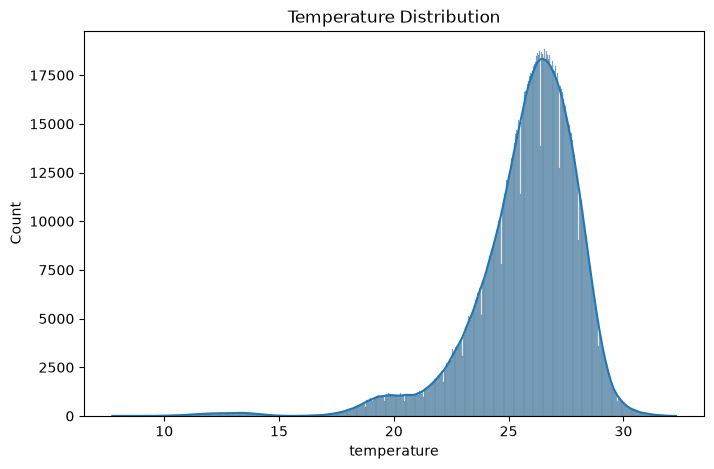

In [13]:
#temperature distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["temperature"],
    kde=True
)

plt.title("Temperature Distribution")
plt.show()

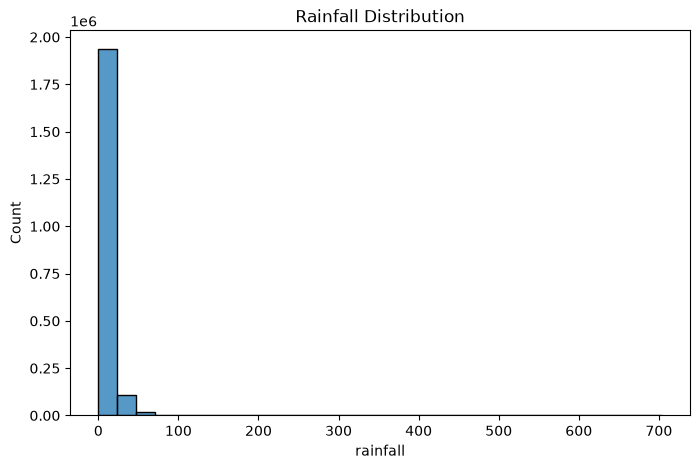

In [14]:
#rainfall distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["rainfall"],
    bins=30
)

plt.title("Rainfall Distribution")
plt.show()

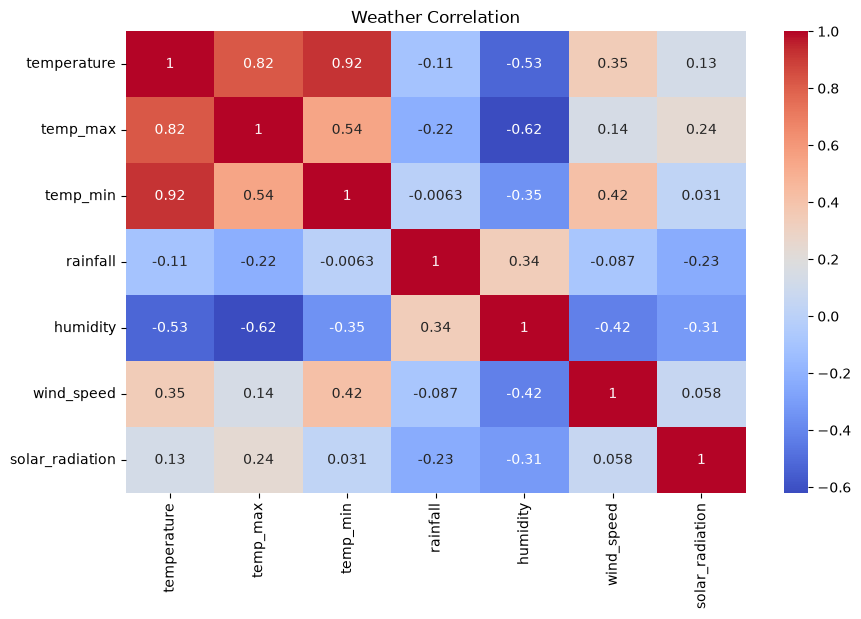

In [16]:
#weather correlation
weather_cols = [
    "temperature",
    "temp_max",
    "temp_min",
    "rainfall",
    "humidity",
    "wind_speed",
    "solar_radiation"
]

corr = df[weather_cols].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Weather Correlation")
plt.show()

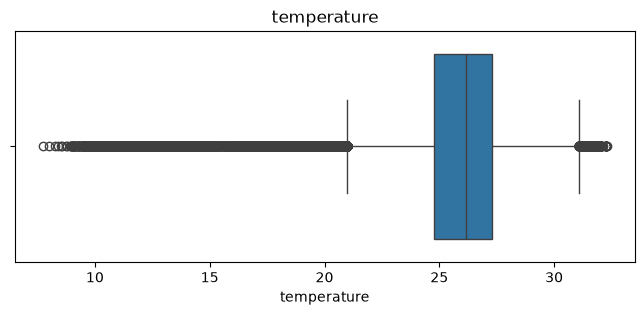

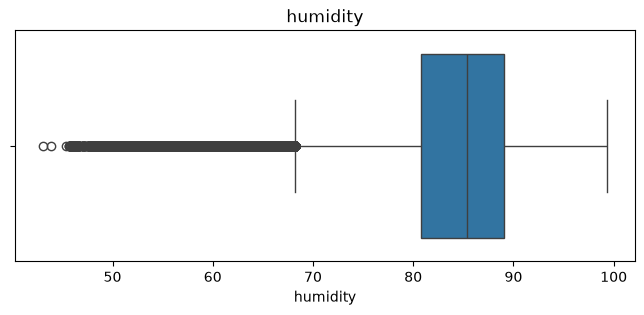

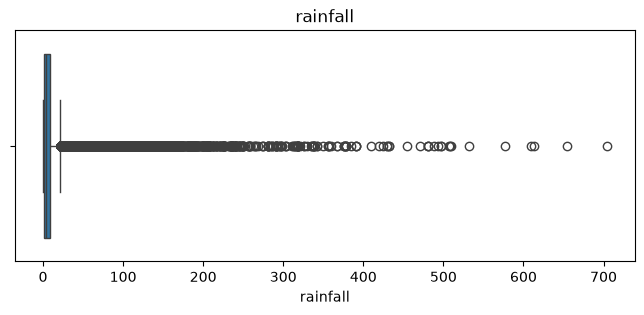

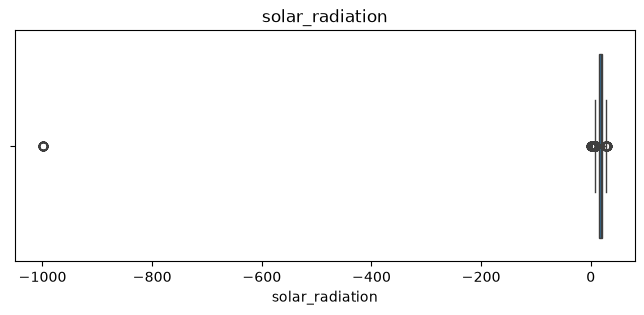

In [18]:
#boxplot outliers
cols = [
    "temperature",
    "humidity",
    "rainfall",
    "solar_radiation"
]

for col in cols:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()